In [112]:
import numpy as np
import matplotlib.pyplot as plt

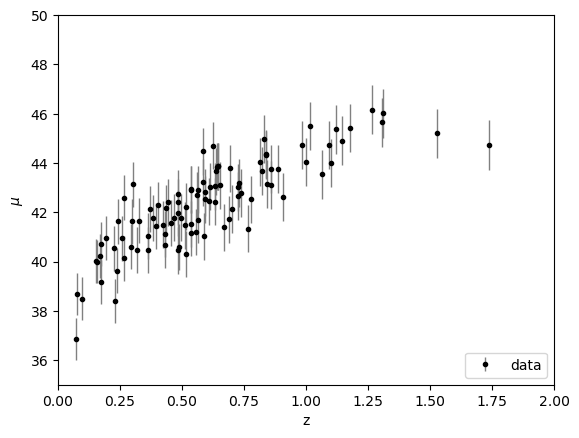

In [113]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [114]:
x_sample = np.reshape(z_sample, [100, 1])
y_sample = mu_sample
x = np.reshape(np.linspace(0, 2, 100), [100, 1])        #how many gaussians

In [115]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
        
kernel1 = 1.0 * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu**2)
gp.fit(x_sample, y_sample)
y_fit, y_std= gp.predict(x, return_std=True)

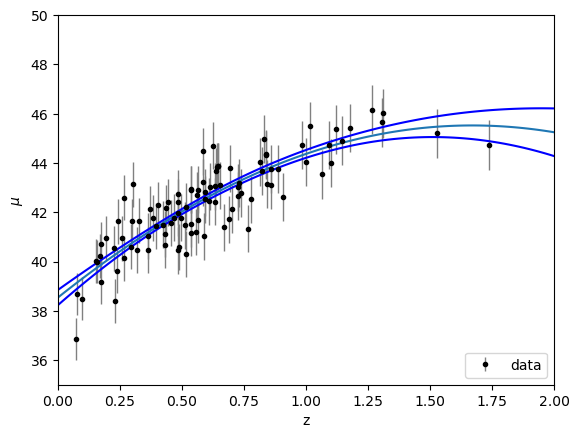

In [116]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.plot(x, y_fit)
plt.plot(x, y_fit + y_std, c="blue")
plt.plot(x, y_fit - y_std, c="blue")

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);